
# Econometric Time-Series Diagnostic Diagnostics for Central Bank Text Sentiment

 Objective: Evaluate the statistical properties of the FinBERT 'Net Tone' series.
 Purpose: Execute Autocorrelation (ACF), Partial Autocorrelation (PACF), 
          and Ljung-Box Q-tests to identify serial correlation or moving-average 
         dependencies. This ensures the baseline series complies with standard 
         Gauss-Markov conditions before running an OLS time-series regression.


<Figure size 1000x500 with 0 Axes>

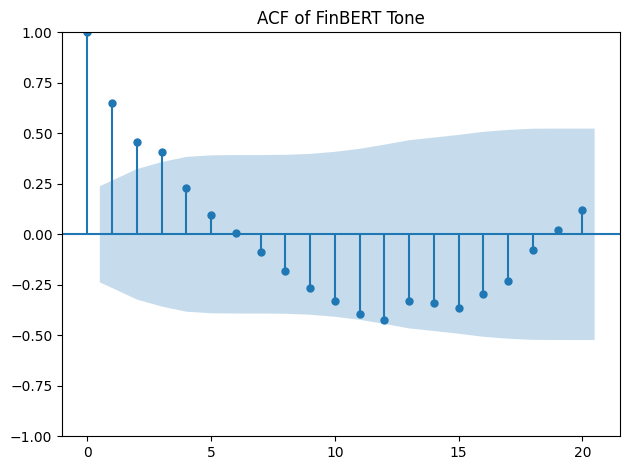

<Figure size 1000x500 with 0 Axes>

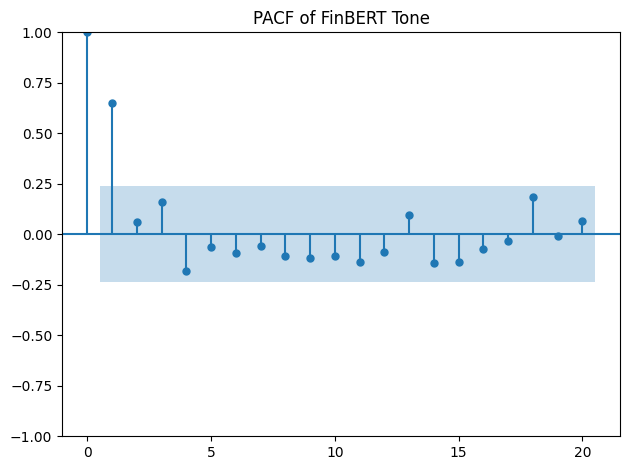

In [19]:
series = df[tone_col].dropna()

plt.figure(figsize=(10, 5))
plot_acf(series, lags=min(20, len(series)//2))
plt.title("ACF of FinBERT Tone")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plot_pacf(series, lags=min(20, len(series)//2), method="ywm")
plt.title("PACF of FinBERT Tone")
plt.tight_layout()
plt.show()

In [20]:
max_lag = min(10, len(series)//4)

ljung = acorr_ljungbox(series, lags=list(range(1, max_lag + 1)), return_df=True)

print("\nLjung-Box test for autocorrelation:")
print(ljung)


Ljung-Box test for autocorrelation:
      lb_stat     lb_pvalue
1   30.061852  4.184831e-08
2   45.148118  1.571125e-10
3   57.450812  2.059084e-12
4   61.386309  1.482852e-12
5   62.094579  4.482715e-12
6   62.096814  1.685985e-11
7   62.713978  4.324757e-11
8   65.348508  4.117794e-11
9   71.147352  9.066758e-12
10  80.163656  4.662981e-13


# Data cleaning of KSE100 

In [73]:
import pandas as pd 
import numpy as np 
KSE_100=pd.read_csv("Karachi 100 Historical Data (1).csv")
KSE_100["Date"]=pd.to_datetime(KSE_100["Date"])



In [74]:

KSE_100["Price"]=KSE_100["Price"].str.replace(',','').astype(float)


In [75]:
KSE_100.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2026-06-12,171075.80,"171,686.16","171,690.20","170,946.55",56.12M,0.81%
1,2026-06-11,169703.59,"168,877.78","170,138.19","168,682.25",186.64M,0.16%
2,2026-06-10,169427.44,"169,734.30","170,729.56","169,346.38",163.01M,-0.53%
3,2026-06-09,170330.56,"170,442.16","171,022.94","170,250.27",209.36M,0.81%
4,2026-06-08,168953.70,"169,254.14","169,360.55","168,432.45",137.85M,-0.89%


In [76]:
KSE_100["log_returns"]=np.log(KSE_100["Price"]/KSE_100["Price"].shift(1))


<Axes: >

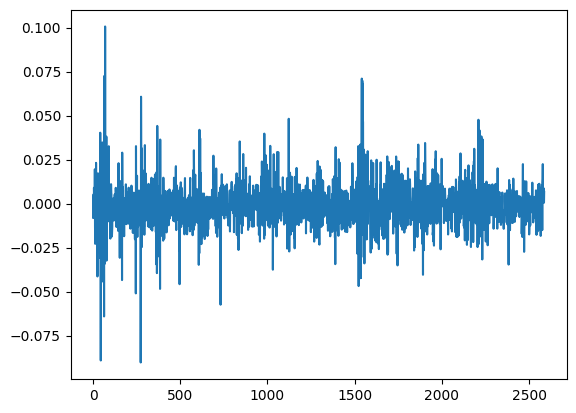

In [77]:
KSE_100["log_returns"].plot()

In [79]:
KSE_100.dropna()

,Date,Price,Open,High,Low,Vol.,Change %,log_returns
1,2026-06-11,169703.59,"168,877.78","170,138.19","168,682.25",186.64M,0.16%,-0.008053
2,2026-06-10,169427.44,"169,734.30","170,729.56","169,346.38",163.01M,-0.53%,-0.001629
3,2026-06-09,170330.56,"170,442.16","171,022.94","170,250.27",209.36M,0.81%,0.005316
4,2026-06-08,168953.70,"169,254.14","169,360.55","168,432.45",137.85M,-0.89%,-0.008116
5,2026-06-05,170478.94,"171,651.48","172,102.91","170,254.66",174.95M,-0.41%,0.008987
...,...,...,...,...,...,...,...,...
2583,2016-01-07,32682.50,"32,964.65","32,964.65","32,652.39",79.28M,-0.87%,0.004528
2584,2016-01-06,32968.26,"33,036.63","33,123.53","32,930.37",61.27M,-0.05%,0.008706
2585,2016-01-05,32983.47,"32,804.32","33,027.33","32,515.05",99.32M,-0.08%,0.000461
2586,2016-01-04,33009.13,"33,265.58","33,304.40","32,968.63",68.94M,-0.66%,0.000778


In [45]:
KSE_100=KSE_100.sort_values("Date")

In [80]:
KSE_100 = KSE_100.sort_values("Date").reset_index(drop=True)


<Axes: >

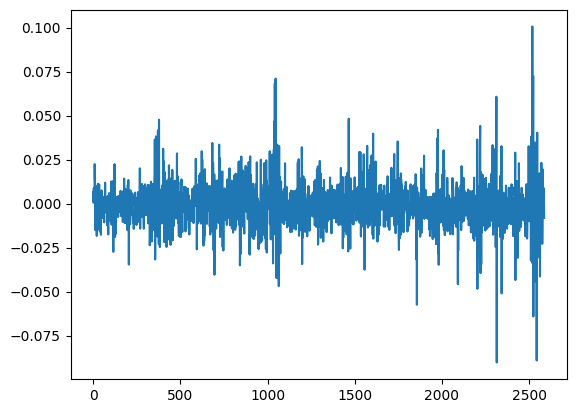

In [82]:
KSE_100['log_returns'].plot()

In [83]:
KSE_100.head()

,Date,Price,Open,High,Low,Vol.,Change %,log_returns
0,2016-01-01,33228.95,"32,841.49","33,256.85","32,828.36",73.48M,1.26%,0.006637
1,2016-01-04,33009.13,"33,265.58","33,304.40","32,968.63",68.94M,-0.66%,0.000778
2,2016-01-05,32983.47,"32,804.32","33,027.33","32,515.05",99.32M,-0.08%,0.000461
3,2016-01-06,32968.26,"33,036.63","33,123.53","32,930.37",61.27M,-0.05%,0.008706
4,2016-01-07,32682.50,"32,964.65","32,964.65","32,652.39",79.28M,-0.87%,0.004528


In [84]:
KSE_100 = KSE_100.reset_index(drop=True)
KSE_100.head()

,Date,Price,Open,High,Low,Vol.,Change %,log_returns
0,2016-01-01,33228.95,"32,841.49","33,256.85","32,828.36",73.48M,1.26%,0.006637
1,2016-01-04,33009.13,"33,265.58","33,304.40","32,968.63",68.94M,-0.66%,0.000778
2,2016-01-05,32983.47,"32,804.32","33,027.33","32,515.05",99.32M,-0.08%,0.000461
3,2016-01-06,32968.26,"33,036.63","33,123.53","32,930.37",61.27M,-0.05%,0.008706
4,2016-01-07,32682.50,"32,964.65","32,964.65","32,652.39",79.28M,-0.87%,0.004528


In [87]:
KSE_100.to_excel("KSE_100.xlsx", index=False)

In [85]:
mpc_files = [
"2016-01-30.txt","2016-04-09.txt","2016-05-21.txt","2016-07-30.txt",
"2016-09-24.txt","2016-11-26.txt","2017-01-28.txt","2017-03-25.txt",
"2017-05-20.txt","2017-07-22.txt","2017-09-29.txt","2017-11-24.txt",
"2018--05-25.txt","2018-01-26.txt","2018-03-30.txt","2018-09-29.txt",
"2018-11-30.txt","2019-01-31.txt","2019-03-29.txt","2019-05-20.txt",
"2019-07-16.txt","2019-11-22.txt","2019-9-16.txt","2020-01-28.txt",
"2020-03-17.txt","2020-03-24.txt","2020-04-16.txt","2020-05-15.txt",
"2020-06-25.txt","2020-09-21.txt","2020-11-23.txt","2021-01-22.txt",
"2021-03-19.txt","2021-05-28.txt","2021-07-27.txt","2021-09-20.txt",
"2021-11-19.txt","2021-12-14.txt","2022-01-24.txt","2022-03-08.txt",
"2022-04-07.txt","2022-05-23.txt","2022-07-07.txt","2022-08-22.txt",
"2022-10-10.txt","2022-11-25.txt","2023-01-23.txt","2023-03-02.txt",
"2023-04-04.txt","2023-06-12.txt","2023-06-26.txt","2023-07-31.txt",
"2023-09-14.txt","2023-10-30.txt","2023-12-12.txt","2024-01-29.txt",
"2024-04-11.txt","2024-06-10.txt","2024-07-29.txt","2024-09-12.txt",
"2024-12-16.txt","2024-29-04.txt","2025-01-27.txt","2025-03-10.txt",
"2025-05-5.txt","2025-06-16.txt","2025-06-30.txt","2025-07-30.txt",
"2025-08-27.txt","2025-12-15.txt"
]

mpc = pd.DataFrame({"file": mpc_files})

mpc["mpc_date"] = (
    mpc["file"]
    .str.replace(".txt", "", regex=False)
    .str.replace("--", "-", regex=False)
)

mpc["mpc_date"] = mpc["mpc_date"].replace({
    "2024-29-04": "2024-04-29"
})

mpc["mpc_date"] = pd.to_datetime(mpc["mpc_date"], errors="coerce")

In [86]:
mpc

,file,mpc_date
0,2016-01-30.txt,2016-01-30
1,2016-04-09.txt,2016-04-09
2,2016-05-21.txt,2016-05-21
3,2016-07-30.txt,2016-07-30
4,2016-09-24.txt,2016-09-24
...,...,...
65,2025-06-16.txt,2025-06-16
66,2025-06-30.txt,2025-06-30
67,2025-07-30.txt,2025-07-30
68,2025-08-27.txt,2025-08-27


In [55]:
matched = pd.merge_asof(
    mpc.sort_values("mpc_date"),
    KSE_100.sort_values("Date"),
    left_on="mpc_date",
    right_on="Date",
    direction="forward"
)

matched[["file", "mpc_date", "Date", "Price", "log_returns"]]

,file,mpc_date,Date,Price,log_returns
0,2016-01-30.txt,2016-01-30,2016-02-01,31878.15,0.018347
1,2016-04-09.txt,2016-04-09,2016-04-11,33566.22,-0.011885
2,2016-05-21.txt,2016-05-21,2016-05-23,36723.35,0.000813
3,2016-07-30.txt,2016-07-30,2016-08-01,39800.64,0.007449
4,2016-09-24.txt,2016-09-24,2016-09-26,40220.76,0.010970
...,...,...,...,...,...
65,2025-06-16.txt,2025-06-16,2025-06-16,122225.36,0.000669
66,2025-06-30.txt,2025-06-30,2025-06-30,125627.31,0.009986
67,2025-07-30.txt,2025-07-30,2025-07-30,138412.25,0.003238
68,2025-08-27.txt,2025-08-27,2025-08-27,147494.03,-0.006360


In [62]:
matched.to_excel("mpc_kse_log_returns.xlsx", index=False)

In [58]:
final_file.to_excel("mpc_kse_log_returns.xlsx", index=False)

NameError: name 'final_file' is not defined

In [60]:
KSE_100["Date"].min(), KSE_100["Date"].max()

(Timestamp('2016-01-04 00:00:00'), Timestamp('2026-06-12 00:00:00'))

In [61]:
KSE_100["year"] = KSE_100["Date"].dt.year
KSE_100["year"].value_counts().sort_index()

year
2016    247
2017    249
2018    246
2019    144
2021      5
2024    140
2025    250
2026    110
Name: count, dtype: int64